In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy.stats import poisson
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import scipy
import os
import re

pd.set_option('display.max_columns', None)


sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
import matplotlib.ticker as ticker

In [26]:
genome_sizes = {
    'kpneumo': 5.5,
    'ecoli': 5,
    'paeruginosa': 6.5
}

In [27]:
df = pd.read_csv("../../data/kpneumoniae/kpneumoniae_data_2023.tsv", sep="\t")

In [28]:
def add_sampling_date(df1, df2, reference_id="Reference", reference_date=""):
    """
    Merges df1 with df2 to add a 'samplingdate' column to df1 based on matching 'ID' in df1 with 'sampleid' in df2.
    
    Parameters:
    df1 (pd.DataFrame): The first dataframe containing 'ID' column.
    df2 (pd.DataFrame): The second dataframe containing 'sampleid' and 'samplingdate' columns.
    
    Returns:
    pd.DataFrame: A new dataframe with the 'samplingdate' column added to df1.
    """
    df = df1.merge(df2[['sampleid', 'samplingdate']], left_on='ID', right_on='sampleid', how='left').drop(columns=['sampleid'])
    
    # Assign reference date if ID matches reference_id
    df.loc[df['ID'] == reference_id, 'samplingdate'] = reference_date
    
    return df

In [29]:
kp_19 = "2021-05-24"
kp_1 = "2020-04-29"
kp_2 = "2019-11-04"
kp_297 = "2021-03-08"
kp_301 = "2022-10-09"
kp_303 = "2020-01-07"
kp_3 = "2020-01-13"
kp_34 = "2020-01-24"
kp_8 = "2019-11-26"
kp_88 = "2021-06-29"
kp_97 = "2021-05-05"
kp_9 = "2020-12-04"

In [30]:
kp_19_7f76e4fb25c45716dce8c351824304ca = pd.read_csv("../../data/kpneumoniae/19_7f76e4fb25c45716dce8c351824304ca/core.txt", sep="\t")
kp_19_9ad54ed389573d35d6ecc8b13fe7a915 = pd.read_csv("../../data/kpneumoniae/19_9ad54ed389573d35d6ecc8b13fe7a915/core.txt", sep="\t")
kp_1_d53ebeed867721d29bb3f0032db17eae = pd.read_csv("../../data/kpneumoniae/1_d53ebeed867721d29bb3f0032db17eae/core.txt", sep="\t")
kp_2_195_bd74056b78d65849726268d251218c19 = pd.read_csv("../../data/kpneumoniae/2_195_bd74056b78d65849726268d251218c19/core.txt", sep="\t")
kp_297_505cec54b2df5fbf196d36a880b8f0e8 = pd.read_csv("../../data/kpneumoniae/297_505cec54b2df5fbf196d36a880b8f0e8/core.txt", sep="\t")
kp_301_634375699c8bdf6a779cc7a062001efc = pd.read_csv("../../data/kpneumoniae/301_634375699c8bdf6a779cc7a062001efc/core.txt", sep="\t")
#core.txt file for kp_302 is emtpy
#kp_302_cf5d1e34ee46818373f5c0affad85bac = pd.read_csv("../../data/kpneumoniae/302_cf5d1e34ee46818373f5c0affad85bac/core.txt", sep="\t")
kp_303_66eb78dba934c4731f8fdad8b13d6596 = pd.read_csv("../../data/kpneumoniae/303_66eb78dba934c4731f8fdad8b13d6596/core.txt", sep="\t")
kp_3_2b6b16ac8bd8d53e9de5acc3ae586fb2 = pd.read_csv("../../data/kpneumoniae/3_2b6b16ac8bd8d53e9de5acc3ae586fb2/core.txt", sep="\t")
kp_34_24b9db63726bbe4d33b9dae6a4da8dc8 = pd.read_csv("../../data/kpneumoniae/34_24b9db63726bbe4d33b9dae6a4da8dc8/core.txt", sep="\t")
kp_34_366bbcdc7cb3f86fc577dcaf77e017d2 = pd.read_csv("../../data/kpneumoniae/34_366bbcdc7cb3f86fc577dcaf77e017d2/core.txt", sep="\t")
kp_34_5483052c1587e00712dda26ec632932a = pd.read_csv("../../data/kpneumoniae/34_5483052c1587e00712dda26ec632932a/core.txt", sep="\t")
kp_34_6b10196a30d5f427674aaed8bcf90e2f = pd.read_csv("../../data/kpneumoniae/34_6b10196a30d5f427674aaed8bcf90e2f/core.txt", sep="\t")
kp_34_ac41b8f86e6c21b847555a2f6165dd9b = pd.read_csv("../../data/kpneumoniae/34_ac41b8f86e6c21b847555a2f6165dd9b/core.txt", sep="\t")
kp_34_ed0366029f8cf66ea622e89cdb037b03 = pd.read_csv("../../data/kpneumoniae/34_ed0366029f8cf66ea622e89cdb037b03/core.txt", sep="\t")
kp_8_103a69895ddee777a49d7528e16c941a = pd.read_csv("../../data/kpneumoniae/8_103a69895ddee777a49d7528e16c941a/core.txt", sep="\t")
kp_88_0505823a8e44e96f291b69c099e13372 = pd.read_csv("../../data/kpneumoniae/88_0505823a8e44e96f291b69c099e13372/core.txt", sep="\t")
kp_97_170c089e0dac23643a5afc931f1094ab = pd.read_csv("../../data/kpneumoniae/97_170c089e0dac23643a5afc931f1094ab/core.txt", sep="\t")
kp_9_9f603c061f921853286f9b2e5fc7cc89 = pd.read_csv("../../data/kpneumoniae/9_9f603c061f921853286f9b2e5fc7cc89/core.txt", sep="\t")

In [31]:
kp_19_7f76e4fb25c45716dce8c351824304ca = add_sampling_date(kp_19_7f76e4fb25c45716dce8c351824304ca, df, reference_date=kp_19)

kp_19_9ad54ed389573d35d6ecc8b13fe7a915 = add_sampling_date(kp_19_9ad54ed389573d35d6ecc8b13fe7a915, df, reference_date=kp_19)

kp_1_d53ebeed867721d29bb3f0032db17eae = add_sampling_date(kp_1_d53ebeed867721d29bb3f0032db17eae, df, reference_date=kp_1)

kp_2_195_bd74056b78d65849726268d251218c19 = add_sampling_date(kp_2_195_bd74056b78d65849726268d251218c19, df, reference_date=kp_2)

kp_297_505cec54b2df5fbf196d36a880b8f0e8 = add_sampling_date(kp_297_505cec54b2df5fbf196d36a880b8f0e8, df, reference_date=kp_297)

kp_301_634375699c8bdf6a779cc7a062001efc = add_sampling_date(kp_301_634375699c8bdf6a779cc7a062001efc, df, reference_date=kp_301)

kp_303_66eb78dba934c4731f8fdad8b13d6596 = add_sampling_date(kp_303_66eb78dba934c4731f8fdad8b13d6596, df, reference_date=kp_303)

kp_3_2b6b16ac8bd8d53e9de5acc3ae586fb2 = add_sampling_date(kp_3_2b6b16ac8bd8d53e9de5acc3ae586fb2, df, reference_date=kp_3)

kp_34_24b9db63726bbe4d33b9dae6a4da8dc8 = add_sampling_date(kp_34_24b9db63726bbe4d33b9dae6a4da8dc8, df, reference_date=kp_34)

kp_34_366bbcdc7cb3f86fc577dcaf77e017d2 = add_sampling_date(kp_34_366bbcdc7cb3f86fc577dcaf77e017d2, df, reference_date=kp_34)

kp_34_5483052c1587e00712dda26ec632932a = add_sampling_date(kp_34_5483052c1587e00712dda26ec632932a, df, reference_date=kp_34)

kp_34_6b10196a30d5f427674aaed8bcf90e2f = add_sampling_date(kp_34_6b10196a30d5f427674aaed8bcf90e2f, df, reference_date=kp_34)

kp_34_ac41b8f86e6c21b847555a2f6165dd9b = add_sampling_date(kp_34_ac41b8f86e6c21b847555a2f6165dd9b, df, reference_date=kp_34)

kp_34_ed0366029f8cf66ea622e89cdb037b03 = add_sampling_date(kp_34_ed0366029f8cf66ea622e89cdb037b03, df, reference_date=kp_34)

kp_8_103a69895ddee777a49d7528e16c941a  = add_sampling_date(kp_8_103a69895ddee777a49d7528e16c941a, df, reference_date=kp_8)

kp_88_0505823a8e44e96f291b69c099e13372 = add_sampling_date(kp_88_0505823a8e44e96f291b69c099e13372, df, reference_date=kp_88)

kp_97_170c089e0dac23643a5afc931f1094ab = add_sampling_date(kp_97_170c089e0dac23643a5afc931f1094ab, df, reference_date=kp_97)

kp_9_9f603c061f921853286f9b2e5fc7cc89 = add_sampling_date(kp_9_9f603c061f921853286f9b2e5fc7cc89, df, reference_date=kp_9)

In [32]:
dataset_dict ={"kp_19_7f76e4fb25c45716dce8c351824304ca":kp_19_7f76e4fb25c45716dce8c351824304ca,
    "kp_19_9ad54ed389573d35d6ecc8b13fe7a915":kp_19_9ad54ed389573d35d6ecc8b13fe7a915,
    "kp_1_d53ebeed867721d29bb3f0032db17eae":kp_1_d53ebeed867721d29bb3f0032db17eae,
    "kp_2_195_bd74056b78d65849726268d251218c19":kp_2_195_bd74056b78d65849726268d251218c19,
    "kp_297_505cec54b2df5fbf196d36a880b8f0e8":kp_297_505cec54b2df5fbf196d36a880b8f0e8,
    "kp_301_634375699c8bdf6a779cc7a062001efc":kp_301_634375699c8bdf6a779cc7a062001efc,
    "kp_303_66eb78dba934c4731f8fdad8b13d6596":kp_303_66eb78dba934c4731f8fdad8b13d6596,
    "kp_3_2b6b16ac8bd8d53e9de5acc3ae586fb2":kp_3_2b6b16ac8bd8d53e9de5acc3ae586fb2,
    "kp_34_24b9db63726bbe4d33b9dae6a4da8dc8":kp_34_24b9db63726bbe4d33b9dae6a4da8dc8,
    "kp_34_366bbcdc7cb3f86fc577dcaf77e017d2":kp_34_366bbcdc7cb3f86fc577dcaf77e017d2,
    "kp_34_5483052c1587e00712dda26ec632932a":kp_34_5483052c1587e00712dda26ec632932a,
    "kp_34_6b10196a30d5f427674aaed8bcf90e2f":kp_34_6b10196a30d5f427674aaed8bcf90e2f,
    "kp_34_ac41b8f86e6c21b847555a2f6165dd9b":kp_34_ac41b8f86e6c21b847555a2f6165dd9b,
    "kp_34_ed0366029f8cf66ea622e89cdb037b03":kp_34_ed0366029f8cf66ea622e89cdb037b03,
    "kp_8_103a69895ddee777a49d7528e16c941a":kp_8_103a69895ddee777a49d7528e16c941a,
    "kp_88_0505823a8e44e96f291b69c099e13372":kp_88_0505823a8e44e96f291b69c099e13372,
    "kp_97_170c089e0dac23643a5afc931f1094ab":kp_97_170c089e0dac23643a5afc931f1094ab,
    "kp_9_9f603c061f921853286f9b2e5fc7cc89":kp_9_9f603c061f921853286f9b2e5fc7cc89
              }

In [33]:
def compute_snps_per_day_withinpatient(dataset_dict):
    """
    Computes the SNPs per day for each sample in each dataset, using the first sampled isolate as reference.

    Parameters:
    dataset_dict (dict): Dictionary where keys are dataset names and values are corresponding DataFrames.

    Returns:
    pd.DataFrame: Output DataFrame with columns ["dataset_name", "sampleid", "snp_count", "days_since_ref", "snp_accumulated", "snps/day"].
    """
    output_data = []

    for dataset_name, df in dataset_dict.items():
        df = df.copy()
        df["samplingdate"] = pd.to_datetime(df["samplingdate"])

        # Identify the first sampled isolate (reference sample)
        reference_sample = df.loc[df["samplingdate"].idxmin()]
        reference_date = reference_sample["samplingdate"]
        reference_snp_count = reference_sample["VARIANT"]

        # Compute days since reference for all samples
        df["days_since_ref"] = (df["samplingdate"] - reference_date).dt.days

        # Compute accumulated SNPs relative to the first sample
        df["snp_accumulated"] = abs(df["VARIANT"] - reference_snp_count)

        # Compute SNPs per day
        snps_per_day_values = []
        for _, row in df.iterrows():
            if row["days_since_ref"] == 0:
                snps_per_day_values.append(row["snp_accumulated"])  # If days = 0, snps/day = snp_accumulated
            else:
                snps_per_day_values.append(row["snp_accumulated"] / row["days_since_ref"])  # Otherwise, divide

        # Assign computed SNPs per day to the df
        df["snps_per_day"] = snps_per_day_values
        
        # Append results with all necessary columns
        output_data.extend(df[["ID", "VARIANT", "days_since_ref", "snp_accumulated", "snps_per_day"]]
                           .assign(dataset_name=dataset_name).values)

    # Convert to DataFrame with correct column names
    output_df = pd.DataFrame(output_data, columns=["sampleid", "snp_count", "days_since_ref", "snp_accumulated", "snps/day", "dataset_name"])

    return output_df

In [34]:
kp_withinpatient = compute_snps_per_day_withinpatient(dataset_dict)

In [35]:
kp_withinpatient

,sampleid,snp_count,days_since_ref,snp_accumulated,snps/day,dataset_name
0,F1S1R1D2B2P1D05,1,0,0,0.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
1,F1S1R1D2B2P2A07,1,1,0,0.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
2,F1S1R1D2B2P2H06,0,1,1,1.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
3,F1S1R1D2B2P5C01,0,11,1,0.090909,kp_19_7f76e4fb25c45716dce8c351824304ca
4,F1S1R1D2B3P2G02,0,18,1,0.055556,kp_19_7f76e4fb25c45716dce8c351824304ca
...,...,...,...,...,...,...
423,F1S1R1D3B3P4G06,3,252,3,0.011905,kp_9_9f603c061f921853286f9b2e5fc7cc89
424,F1S1R1D3B3P4H06,3,252,3,0.011905,kp_9_9f603c061f921853286f9b2e5fc7cc89
425,F1S1R1D3B3P5F03,3,258,3,0.011628,kp_9_9f603c061f921853286f9b2e5fc7cc89
426,F1S1R1D3B3P5G03,3,258,3,0.011628,kp_9_9f603c061f921853286f9b2e5fc7cc89


In [36]:
def compute_snps_per_day(dataset_dict):
    """
    Computes the SNPs per day for each sample in each dataset provided in the dataset dictionary.

    Parameters:
    dataset_dict (dict): Dictionary where keys are dataset names and values are corresponding DataFrames.

    Returns:
    pd.DataFrame: Output DataFrame with columns ["dataset_name", "sampleid", "snp_count", "days_since_ref", "snps/day"].
    """
    output_data = []

    for dataset_name, df in dataset_dict.items():
        df = df.copy()
        df["samplingdate"] = pd.to_datetime(df["samplingdate"])

        # Identify the reference sample (VARIANT == 0)
        reference_row = df[df["VARIANT"] == 0]
        if reference_row.empty:
            continue  # Skip dataset if no reference sample found

        # Get the earliest reference date
        reference_date = reference_row["samplingdate"].min()

        # Compute days since reference for all samples (including reference)
        df["days_since_ref"] = (df["samplingdate"] - reference_date).dt.days

        # Compute SNPs per day, ensuring reference samples have snps/day = 0
        df["snps_per_day"] = df["VARIANT"] / df["days_since_ref"]
        df.loc[df["VARIANT"] == 0, "snps_per_day"] = 0  # Explicitly set SNPs/day to 0 for reference

        # Replace infinite values (division by zero) and drop NaNs
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(subset=["snps_per_day"], inplace=True)

        # Append results with all necessary columns
        output_data.extend(df[["ID", "VARIANT", "days_since_ref", "snps_per_day"]]
                           .assign(dataset_name=dataset_name).values)

    # Convert to DataFrame with correct column names
    output_df = pd.DataFrame(output_data, columns=["sampleid", "snp_count", "days_since_ref", "snps/day", "dataset_name"])

    return output_df

In [37]:
kp_clockrates = compute_snps_per_day(dataset_dict)

In [38]:
kp_clockrates

,sampleid,snp_count,days_since_ref,snps/day,dataset_name
0,F1S1R1D2B2P2A07,1,1,1.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
1,F1S1R1D2B2P2H06,0,1,0.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
2,F1S1R1D2B2P5C01,0,11,0.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
3,F1S1R1D2B3P2G02,0,18,0.000000,kp_19_7f76e4fb25c45716dce8c351824304ca
4,F1S1R1D2B3P4H09,1,25,0.040000,kp_19_7f76e4fb25c45716dce8c351824304ca
...,...,...,...,...,...
422,F1S1R1D3B3P4G06,3,252,0.011905,kp_9_9f603c061f921853286f9b2e5fc7cc89
423,F1S1R1D3B3P4H06,3,252,0.011905,kp_9_9f603c061f921853286f9b2e5fc7cc89
424,F1S1R1D3B3P5F03,3,258,0.011628,kp_9_9f603c061f921853286f9b2e5fc7cc89
425,F1S1R1D3B3P5G03,3,258,0.011628,kp_9_9f603c061f921853286f9b2e5fc7cc89


In [39]:
color_mapping_kp = {
    "kp_34": "#f97306",
    "kp_297": "#8f1402",
    "kp_303": "#cb416b",
    "kp_19": "#cb416b",
    "kp_1": "#e50000",
    "kp_15": "#a52a2a",
    "kp_2": "#800000",
    "kp_3": "#c04e01",
    "kp_301": "#b22222", 
    "kp_302": "#ff4500",
    "kp_8": "#ff6347", 
    "kp_88": "#cc4e5c",
    "kp_9": "#ff2400",
    "kp_97": "#c32148" 
}

In [40]:
def extract_dataset_prefix(dataset_name):
    """Extracts the dataset prefix (e.g., 'kp_19') from the full dataset name."""
    match = re.match(r'^(kp_\d+)', str(dataset_name))
    return match.group(1) if match else "unknown"

def filter_outliers_poisson(dataframe, snps_column):
    """Filters out Poisson-based outliers from the SNPs per day column and returns removed values."""
    mean_value = dataframe[snps_column].mean()
    threshold = stats.poisson.ppf(0.95, mean_value)  # 95th percentile of Poisson distribution
    
    filtered_df = dataframe.loc[dataframe[snps_column] <= threshold].copy()
    outliers_df = dataframe.loc[dataframe[snps_column] > threshold].copy()
    
    return filtered_df, outliers_df

def plot_snps_rates(dataframe, dataset_column="dataset_name", snps_column="snps/day",
                   save_path=None, file_name=""):
    """
    Plots SNP rates in two subplots:
    1. SNPs per day
    2. SNPs per Mb per year
    
    Parameters:
    dataframe (pd.DataFrame): Input DataFrame containing dataset names and SNPs/day values.
    dataset_column (str): Column name representing dataset names (x-axis).
    snps_column (str): Column name representing SNPs per day (y-axis).
    """
    # Extract dataset prefixes for consistent color mapping
    dataframe = dataframe.copy()
    dataframe.loc[:, "dataset_prefix"] = dataframe[dataset_column].apply(extract_dataset_prefix)
    
    # Filter outliers using Poisson distribution
    filtered_df, outliers_df = filter_outliers_poisson(dataframe, snps_column)
    
    # Compute mutation rate per Mb per year (corrected formula: 1 SNP/day * 365 / 5.5 Mb)
    filtered_df["snps_per_Mb_per_year"] = filtered_df[snps_column] * 365 / 5.7
    
    # Aggregate SNP data: Compute mean and standard deviation for each dataset prefix
    summary_df = filtered_df.groupby("dataset_prefix")[[snps_column, "snps_per_Mb_per_year"]].agg(['mean', 'std']).reset_index()
    summary_df.columns = ['dataset_prefix', 'mean_snps_day', 'std_snps_day', 'mean_snps_Mb_year', 'std_snps_Mb_year']
    
    # Sort datasets by mean SNPs/day for better visualization
    summary_df = summary_df.sort_values(by="mean_snps_day")
    print(summary_df)
    
    # Define color mapping
    color_mapping_kp = {
        "kp_34": "#f97306", "kp_297": "#8f1402", "kp_303": "#cb416b", "kp_19": "#cb416b", 
        "kp_1": "#e50000", "kp_15": "#a52a2a", "kp_2": "#800000", "kp_3": "#c04e01", 
        "kp_301": "#b22222", "kp_302": "#ff4500", "kp_8": "#ff6347", "kp_88": "#cc4e5c", 
        "kp_9": "#ff2400", "kp_97": "#c32148"
    }
    
    # Assign colors based on dataset prefix
    summary_df["color"] = summary_df["dataset_prefix"].map(color_mapping_kp).fillna("black")
    
    # Set seaborn style
    sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
    sns.set_context('talk')
    
    # Set font settings
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial']
    
    # Set up the figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
    
    # First plot: SNPs per day
    for i, row in summary_df.iterrows():
        axes[0].errorbar(
            x=row["dataset_prefix"], 
            y=row["mean_snps_day"], 
            yerr=row["std_snps_day"], 
            fmt="o", 
            markersize=0, 
            capsize=5, 
            linestyle="None", 
            color=row["color"]
        )
    axes[0].scatter(
        summary_df["dataset_prefix"], 
        summary_df["mean_snps_day"], 
        c=summary_df["color"], 
        s=200, 
        edgecolor="none"
    )
    axes[0].set_ylabel("mutation rate/day", fontsize=18)
    axes[0].set_ylim(0, None)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].set_title("$K.$ $pneumoniae$ molecular clock rates", fontsize=20)
    axes[0].grid(False)
    
    # Second plot: SNPs per Mb per year
    for i, row in summary_df.iterrows():
        axes[1].errorbar(
            x=row["dataset_prefix"], 
            y=row["mean_snps_Mb_year"], 
            yerr=row["std_snps_Mb_year"], 
            fmt="o", 
            markersize=0, 
            capsize=5, 
            linestyle="None", 
            color=row["color"]
        )
    axes[1].scatter(
        summary_df["dataset_prefix"], 
        summary_df["mean_snps_Mb_year"], 
        c=summary_df["color"], 
        s=200, 
        edgecolor="none"
    )
    axes[1].set_ylabel("Mutation rate per Mb per year", fontsize=18)
    axes[1].set_ylim(0, None)
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].set_xlabel("", fontsize=18)
    axes[1].grid(False)
    
    # Adjust layout
    plt.xticks(rotation=0, ha="right", fontsize=14)
    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        png_path = os.path.join(save_path, f"{file_name}.png")
        svg_path = os.path.join(save_path, f"{file_name}.svg")
        plt.savefig(png_path, dpi=150, bbox_inches='tight')
        plt.savefig(svg_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {png_path} and {svg_path}")
        
    plt.show();

In [41]:
filtered_df, outliers_df = filter_outliers_poisson(kp_clockrates, "snps/day")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

   dataset_prefix  mean_snps_day  std_snps_day  mean_snps_Mb_year  \
0            kp_1       0.021984      0.056025           1.407728   
5          kp_301       0.031705      0.015034           2.030205   
2            kp_2       0.734356      0.182430          47.024577   
7           kp_34       1.230876      4.443516          78.819271   
4            kp_3       1.840354      3.312103         117.847199   
11          kp_97       4.139715      1.609469         265.086998   
8            kp_8       4.417458      2.360501         282.872333   
6          kp_303       4.552440      0.981047         291.515918   
1           kp_19       6.963372     10.486855         445.900163   
3          kp_297       7.776656      3.849198         497.978827   
10           kp_9      10.115224     11.004673         647.729230   
9           kp_88      13.378701      7.061032         856.706299   

    std_snps_Mb_year  
0           3.587546  
5           0.962681  
2          11.681939  
7         

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Plot saved to ../../out/figures/unfiltered_clockrates_kp.png and ../../out/figures/unfiltered_clockrates_kp.svg


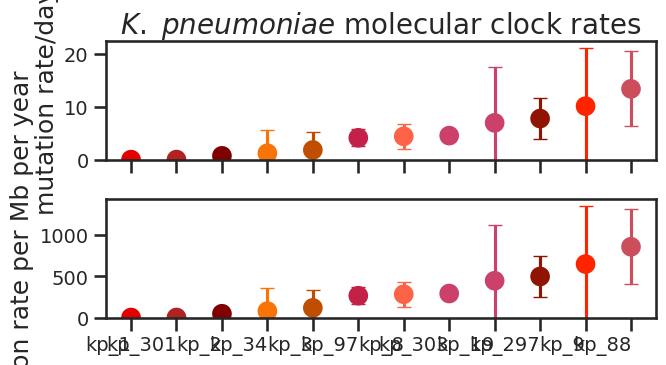

In [42]:
plot_snps_rates(kp_clockrates, save_path="../../out/figures/", file_name="unfiltered_clockrates_kp")

   dataset_prefix  mean_snps_day  std_snps_day  mean_snps_Mb_year  \
3          kp_297       0.000000           NaN           0.000000   
0            kp_1       0.021984      0.056025           1.407728   
5          kp_301       0.031705      0.015034           2.030205   
9           kp_88       0.034858      0.060376           2.232160   
1           kp_19       0.044404      0.186180           2.843439   
10           kp_9       0.193194      0.275432          12.371226   
4            kp_3       0.545080      0.202058          34.904262   
2            kp_2       0.734356      0.182430          47.024577   
7           kp_34       0.868550      0.563448          55.617657   
11          kp_97       4.139715      1.609469         265.086998   
8            kp_8       4.249833      2.320093         272.138411   
6          kp_303       4.552440      0.981047         291.515918   

    std_snps_Mb_year  
3                NaN  
0           3.587546  
5           0.962681  
9         

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Plot saved to ../../out/figures/filtered_clockrates_kp.png and ../../out/figures/filtered_clockrates_kp.svg


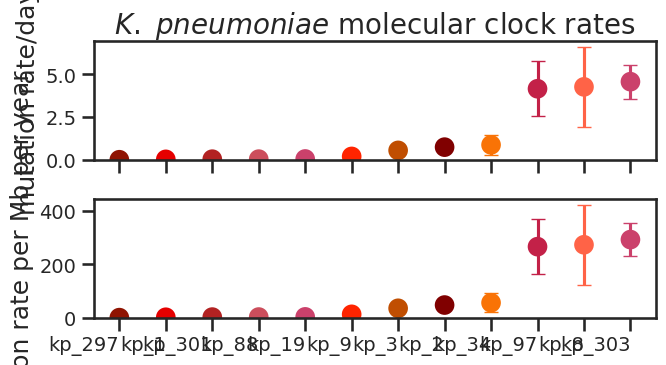

In [43]:
plot_snps_rates(filtered_df, save_path="../../out/figures/", file_name="filtered_clockrates_kp")

In [44]:
kp_19_9ad54ed389573d35d6ecc8b13fe7a915

,ID,LENGTH,ALIGNED,UNALIGNED,VARIANT,HET,MASKED,LOWCOV,samplingdate
0,F1S1R2D2B1P1A05,5740642,4977483,753458,5735,1390,0,8311,2022-01-17
1,F1S1R2D2B1P1A11,5740642,4979037,752485,5737,1266,0,7854,2022-01-17
2,F1S1R2D2B1P1C06,5740642,4970573,754842,5566,3520,0,11707,2022-01-17
3,F1S1R2D2B1P1E05,5740642,4968975,754262,5546,4128,0,13277,2022-01-17
4,F1S1R2D2B1P3C05,5740642,4979871,753235,5586,1265,0,6271,2022-01-24
5,F1S1R2D2B1P4B07,5740642,4976062,754078,5576,1565,0,8937,2022-01-27 00:00:00
6,F1S1R2D2B1P4C07,5740642,4973563,753735,5556,2268,0,11076,2022-01-27 00:00:00
7,F1S1R2D2B2P1E02,5740642,4969802,748603,5390,6290,0,15947,2022-01-31
8,F1S1R2D2B2P2A12,5740642,4971406,750811,5449,2700,0,15725,2022-02-08
9,F1S1R2D2B2P2H11,5740642,4983508,743334,5467,1054,0,12746,2022-02-08


In [45]:
kp_19_7f76e4fb25c45716dce8c351824304ca

,ID,LENGTH,ALIGNED,UNALIGNED,VARIANT,HET,MASKED,LOWCOV,samplingdate
0,F1S1R1D2B2P1D05,5740642,5724762,11196,1,596,0,4088,2021-05-24
1,F1S1R1D2B2P2A07,5740642,5719852,11627,1,1105,0,8058,2021-05-25
2,F1S1R1D2B2P2H06,5740642,5723130,12004,0,787,0,4721,2021-05-25
3,F1S1R1D2B2P5C01,5740642,5723202,11298,0,931,0,5211,2021-06-04
4,F1S1R1D2B3P2G02,5740642,5722750,11340,0,572,0,5980,2021-06-11
5,F1S1R1D2B3P4H09,5740642,5723425,11128,1,846,0,5243,2021-06-18
6,F1S1R1D2B4P2C09,5740642,5696117,38441,3,882,0,5202,2021-06-23
7,F1S1R1D2B4P3A07,5740642,5722685,11444,0,681,0,5832,2021-06-25
8,F1S1R1D3B4P1G01,5740642,5723920,10980,2,818,0,4924,2021-08-20
9,F1S1R1D3B4P1H01,5740642,5724132,13148,11,647,0,2715,2021-08-20


In [46]:
def plot_filtered_snps_histogram(filtered_df, outliers_df, snps_column="snps/day",
                                save_path=None, file_name=""):
    """Plots a histogram of SNPs per day, showing both passing and filtered SNPs,
    with a fitted Poisson distribution curve scaled to a secondary y-axis."""
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Combine both datasets to ensure proper bin alignment
    all_snps = pd.concat([filtered_df[snps_column], outliers_df[snps_column]])
    
    # Define bins to ensure consistency between both histograms (increase bin count for better resolution)
    bins = np.histogram_bin_edges(all_snps, bins=15)
    
    # Plot histogram with different colors for passing and filtered SNPs
    sns.histplot(filtered_df[snps_column], bins=bins, color="blue", label="Passing SNPs", alpha=0.7, edgecolor=None, ax=ax1)
    sns.histplot(outliers_df[snps_column], color="red", label="Filtered SNPs", alpha=0.7, edgecolor=None, ax=ax1)
    
    # Create secondary axis for Poisson fit
    ax2 = ax1.twinx()
    
    # Fit and plot a Poisson distribution line over all SNP data
    lambda_poisson = np.mean(all_snps)
    x_values = np.arange(0, int(max(all_snps)) + 1)
    poisson_pmf = stats.poisson.pmf(x_values, lambda_poisson)
    
    ax2.plot(x_values, poisson_pmf, color="lightgrey", linewidth=2, label="Poisson Fit")
    ax2.set_ylabel("Poisson Probability", fontsize=18)
    ax2.tick_params(axis='y', labelsize=14)
    
    ax1.set_xlabel("SNPs per day", fontsize=18)
    ax1.set_ylabel("Frequency", fontsize=18)
    ax1.tick_params(axis='both', labelsize=14)
    ax1.set_title("Distribution of SNPs per day (Passing vs. Filtered)", fontsize=18)
    
    # Set legend face color to white
    legend = ax1.legend()
    legend.get_frame().set_facecolor("white")
    
    ax1.text(0.6, 0.65, "95% Poisson distribution", transform=ax1.transAxes, fontsize=12, color="black")

    ax1.grid(False)
    ax1.set_ylim(0, None)  # Set primary y-axis to start at 0
    ax2.set_ylim(0, None)  # Set secondary y-axis to start at 0
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        png_path = os.path.join(save_path, f"{file_name}.png")
        svg_path = os.path.join(save_path, f"{file_name}.svg")
        plt.savefig(png_path, dpi=150, bbox_inches='tight')
        plt.savefig(svg_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {png_path} and {svg_path}")
        
    plt.show();

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Plot saved to ../../out/figures/filtered_snps_kp.png and ../../out/figures/filtered_snps_kp.svg


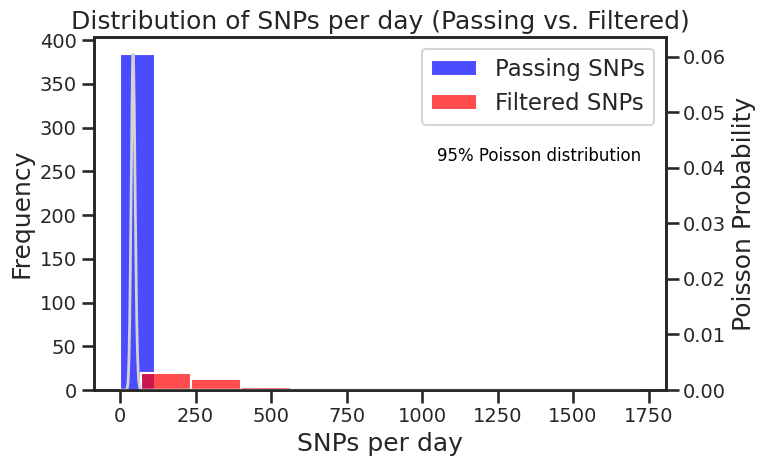

In [47]:
filtered_df, outliers_df = filter_outliers_poisson(kp_clockrates, "snps/day")
plot_filtered_snps_histogram(filtered_df, outliers_df,
                            save_path="../../out/figures/", file_name="filtered_snps_kp")